# Project 3: Boston Weather Analysis, 1960–2025

## Overview

This project uses daily weather observations from Boston Logan International Airport from January 1, 1960 to August 27, 2025 (23,980 days), downloaded from the NOAA NCEI Global Surface Summary of the Day (GSOD).

Your goal is to describe how Boston's weather has changed over the past 65 years and to judge whether the data shows signs of a warming climate. Temperature is the obvious place to start, but do not stop there: look at precipitation, snow, wind, thunderstorms, extreme days, and the timing of the seasons.

## Column definitions

Source: NOAA NCEI GSOD, station 72509014739 (Boston Logan International Airport), January 1960 to August 2025.

| Column | Definition | Unit |
|---|---|---|
| `date` | Observation date | YYYY-MM-DD |
| `avg_temp_f` | Mean temperature for the day | °F |
| `max_temp_f` | Highest temperature reported during the day | °F |
| `min_temp_f` | Lowest temperature reported during the day | °F |
| `precip_in` | Total precipitation (rain plus melted snow) | inches |
| `snow_depth_in` | Snow depth on the ground, from the last report of the day | inches |
| `wind_knots` | Mean wind speed for the day | knots (1 knot ≈ 1.15 mph) |
| `gust_knots` | Maximum wind gust reported | knots |
| `visibility_mi` | Mean visibility for the day | miles |
| `weather_flags` | 6-digit indicator (FRSHTT) for Fog, Rain/drizzle, Snow/ice pellets, Hail, Thunder, Tornado | code |
| `fog`, `rain`, `snow`, `hail`, `thunder`, `tornado` | One column per `weather_flags` digit | 1 = occurred, 0 = did not |
| `year` | Year of `date` | integer |
| `month` | Month of `date` | 1–12 |
| `day` | Day of the month of `date` | 1–31 |
| `year_month` | Year and month of `date` | YYYY-MM |

**Notes**
- Missing-value codes (9999.9, 999.9, 99.99) were replaced with nulls.
- Max/min temperatures may include part of the previous day.
- A precipitation value of 0.00 can mean either no rain or no report.
- `weather_flags` is stored as a number, so leading zeros are lost (`010010` appears as `10010`). Use the six flag columns instead.

## Know your data before you analyze it

Not every column was recorded the same way for all 65 years. A change in how something was measured can look exactly like a change in the weather. Check how complete a column is over time before you draw a conclusion from it.

| Column | Problem | What to do |
|---|---|---|
| `precip_in` | 0 or missing on every day from 1960 to 1972. 1989 and 1992 are missing about a quarter of their days, and the 1973 total (81.9 in) is far above any other year. | Use 1974 onward for precipitation, and leave out or flag incomplete years. |
| `snow_depth_in` | Reported on 12% of days at most in any decade, and not at all in the 1960s or since 2010. | Do not use it. Use the `snow` flag to count snow days instead. |
| `gust_knots` | Not recorded in the 1960s, and missing on 30–55% of days after that. | Use only days where it is present, and say so. |
| `visibility_mi` | Capped at 10 miles from 1997, when the airport switched to automated instruments. | Do not compare values before and after 1997. |
| `fog` | Falls from about 38% of days to under 10% starting in 2005, because of a reporting change. | Do not treat it as a climate trend. |
| `wind_knots` | Drops by about 1 knot around 1996–97, at the same time as the instrument change. | Be careful interpreting a sudden change there. |
| 2025 | Only January through August. | Leave 2025 out of yearly totals and averages, or compare the same months in every year. |

## Your task

1. **Ask 10 questions** that the data can answer and that tell us something about how Boston's weather has changed. Label them Question 1 through Question 10.
2. **Go beyond temperature.** Use at least five different columns across your ten questions, and make no more than four of your questions mainly about temperature.
3. **Use window functions.** At least 7 of your 10 questions must use a window function, and across the project you must use at least three of these kinds:
   - an aggregate over a partition (e.g., each day compared with its month or decade)
   - a ranking function (`rank`, `dense_rank`, `row_number`, `percent_rank`, `ntile`)
   - `lag` or `lead`
   - a moving or running window (`rowsBetween` / `rangeBetween`)
4. **Do the analysis in PySpark.** Use pandas only to bring a small, final result into a chart with `toPandas()`.
5. **Visualize every question.** Pick a chart that suits the result, and give it a title, axis labels with units, and a legend when there is more than one series. For long-term trends, a trend line or decade averages make the pattern easier to see.

Some directions to explore (you are not required to use these): extreme hot and cold days, the length of the freeze-free season, heat waves, heavy-rain days, snow days per winter, thunderstorms, windy days, and day-to-day temperature swings.

## Format for each question

```
### Question N: <your question>
Markdown: what you are asking and why it matters (1–2 sentences)
Code:     the PySpark query, with show() on the result
Code:     the chart
Markdown: what you found, citing specific numbers (2–4 sentences)
```

## Summary of findings

End the notebook with 3–5 paragraphs that:
- summarize your most important findings
- state whether the data supports a warming climate in Boston, and which of your questions are the strongest and weakest evidence
- explain how the data problems above limited what you could conclude

## Submission

Submit both the `.ipynb` file and an HTML export with every output visible.

# Import function and load weather data

In [15]:
import sys
from pyspark.sql import SparkSession
from pyspark.sql.utils import AnalysisException
import pyspark.sql.functions as F
import pyspark.sql.types as T
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.window import Window

import warnings
warnings.filterwarnings('ignore')

# change the account name to your email account
account='sli'

# define a root path to access the data in the DataAnalysisWithPythonAndPySpark
data_path='/net/clusterhn/home/'+account+'/isa460/data/'

# check if the Spark session is active. If it is activate, close it

try:
    if spark:
        spark.stop()
except:
    pass    

spark = (SparkSession.builder.appName("Boston Weather Analysis")
        .config("spark.port.maxRetries", "100")
        .config("spark.sql.mapKeyDedupPolicy", "LAST_WIN")  # This configuration allow the duplicate keys in the map data type.
         .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
        .config("spark.driver.memory", "8g")
        .config("spark.driver.executor","8g")
        .getOrCreate())

# confiture the log level (defaulty is WARN)
spark.sparkContext.setLogLevel('ERROR')

In [16]:
df=spark.read.parquet(data_path+'boston_logan_weather_1960_2025.parquet')

# Sample question -average temperture by year

In [13]:
# 2025 only has January to August, so leave it out of yearly averages

df1=df.where('year <= 2024').groupBy('year').agg(F.avg('avg_temp_f').alias('avg_temp')).orderBy('year')

df1.show()

+----+------------------+
|year|          avg_temp|
+----+------------------+
|1960| 50.92896174863385|
|1961| 50.64931506849318|
|1962|49.452602739726046|
|1963| 50.54794520547943|
|1964| 49.90191256830601|
|1965| 49.30739726027402|
|1966|  51.1750684931507|
|1967| 49.23506849315069|
|1968| 50.15479452054794|
|1969|50.994520547945235|
|1970|50.716986301369886|
|1971| 50.84054794520551|
|1972|50.043989071038254|
|1973|52.622739726027426|
|1974|50.673424657534234|
|1975| 52.65287671232871|
|1976| 51.91584699453553|
|1977| 52.24109589041096|
|1978| 50.22301369863013|
|1979| 51.73452054794523|
+----+------------------+
only showing top 20 rows



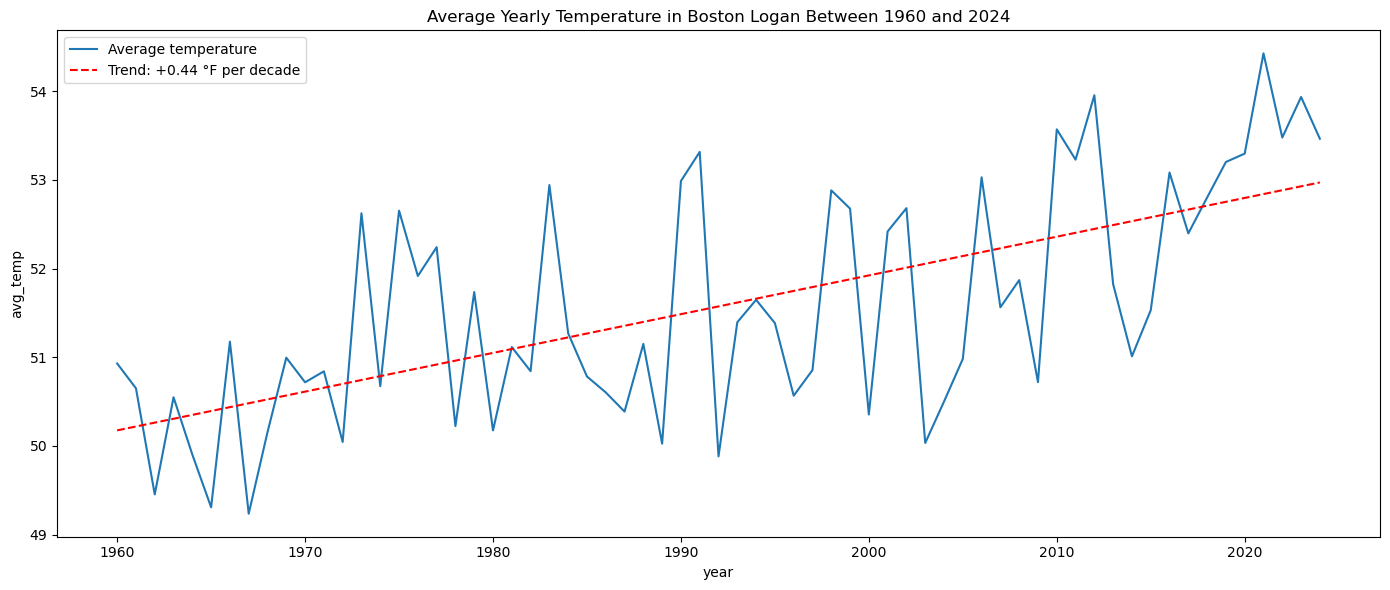

In [14]:
# visualize the result
import numpy as np

result = df1.toPandas()

plt.figure(figsize=(14, 6))

ax = sns.lineplot(data=result, x='year', y='avg_temp', label='Average temperature')

# Linear trend line
slope, intercept = np.polyfit(result['year'], result['avg_temp'], 1)
ax.plot(result['year'], slope * result['year'] + intercept,
        color='red', linestyle='--',
        label=f'Trend: {slope * 10:+.2f} °F per decade')

plt.title('Average Yearly Temperature in Boston Logan Airport Between 1960 and 2024')

plt.legend()
plt.tight_layout()
plt.show()